# Causal Inference with Neural Networks: TARNet, CFR, and Dragonnet

**Author:** Peter Zhang  
**Date:** May 2026

---

Estimating the Individual Treatment Effect (ITE) from observational data is a fundamental challenge in causal inference. Unlike standard machine learning, which focuses on predicting outcomes based on passive correlation, causal inference aims to answer counterfactual questions: *What would have happened if we had intervened differently?* For example, in medicine, we want to know whether a patient would recover faster if given a specific treatment compared to a control.

The major hurdle is that we never observe both outcomes for the same individual. This is known as the **fundamental problem of causal inference**. Because the counterfactual is always unobserved, we must rely on advanced models to estimate the missing potential outcomes.

---

## Notebook Catalog
1. [Problem Setting and Motivation](#1.-Problem-Setting-and-Motivation)
2. [Dataset & Realization Disclaimer](#2.-Dataset-&-Realization-Disclaimer)
3. [Treatment-Agnostic Representation Network (TARNet)](#3.-Treatment-Agnostic-Representation-Network-(TARNet))
4. [Counterfactual Regression (CFR)](#4.-Counterfactual-Regression-(CFR))
5. [Dragonnet](#5.-Dragonnet)
6. [Visualizing the Learned Representations](#6.-Visualizing-the-Learned-Representations)

---

## 1. Problem Setup and Motivation

Recall that in the framework of the Rubin Causal Model, we characterize each individual by a set of background covariates $X$, a binary treatment assignment $T \in \{0, 1\}$, and an observed outcome $Y$. For every individual, there exist two potential outcomes: $Y(0)$ represents the potential outcome under the control condition, and $Y(1)$ represents the potential outcome under the active treatment condition. 

Crucially, the observed outcome is a combination of these potential outcomes, dynamically selected by the actual treatment assignment:
$$ Y = (1 - T)Y(0) + T Y(1) $$

Our goal is to estimate the **Individual Treatment Effect (ITE)**, denoted as $\tau(X) = \mathbb{E}[Y(1) - Y(0) \mid X]$, which measures the expected change in the potential outcome for an individual with covariates $X$. Aggregating this across the population yields the **Average Treatment Effect (ATE)**, defined as $\text{ATE} = \mathbb{E}[Y(1) - Y(0)]$. 

### The Limits of Classical Meta-Learners

Traditional machine learning approaches generally tackle this problem using two standard meta-learners, both of which suffer from distinct structural limitations:

The **S-Learner (Single Learner)** concatenates the covariates and the treatment assignment into a single feature vector $[X, T]$ and trains a single model to predict the outcome $Y$. While conceptually simple, this approach often fails in high-dimensional settings. Because the binary treatment indicator $T$ is only a single feature among many dimensions in $X$, deep neural networks frequently regularize away or ignore the treatment variable altogether. This leads to treatment effect estimates that collapse to zero, as the model fails to capture the unique influence of the intervention.

Conversely, the **T-Learner (Two Learners)** trains two entirely separate models: one model $\mu_0(X)$ to predict the control outcome and another model $\mu_1(X)$ to predict the treated outcome. While this prevents the treatment variable from being ignored, it is highly data-inefficient. Because the two models share no parameters, they cannot learn from shared underlying relationships between the covariates $X$ and the outcome $Y$ that remain invariant across both treatment groups. This is particularly problematic in observational datasets where one treatment group may have very sparse coverage in certain regions of the covariate space.

### Shared Representation Learning as the Bridge

To overcome these structural limitations, modern deep learning architectures learn a **shared latent representation** $\Phi(X)$ that is common to both treatment groups, and then branch into separate, treatment-specific **hypothesis heads** (or outcome heads) to predict the outcomes $\hat{Y}(0)$ and $\hat{Y}(1)$. This shared representation structure forces the network to learn a rich, shared feature space from the entire dataset (solving the T-learner's data inefficiency), while the physical separation of the prediction heads guarantees that the treatment assignment dynamically drives distinct outcomes (solving the S-learner's treatment-ignorance problem).

In this notebook, we explore the progression of this paradigm. We begin by evaluating **TARNet** (Treatment-Agnostic Representation Network), which establishes this shared representation framework. We then implement **Counterfactual Regression (CFR)**, which adds balance regularization (MMD or Wasserstein distance) to the representation space to address selection bias. Finally, we implement **Dragonnet**, which uses a propensity score head as a targeted regularizer to preserve vital confounding variables.

## 2. Dataset

To see these neural network architectures in action, we are going to use the **Infant Health and Development Program (IHDP)** dataset. Originally a randomized clinical trial focused on the effects of home visits on low-birth-weight infants, the IHDP dataset has become a gold-standard benchmark in the causal inference community. 

Why is it so widely used? Because it is *semi-simulated*. The background covariates $X$ and treatment assignments $T$ are from the real clinical trial, but the potential outcomes $Y(0)$ and $Y(1)$ are simulated using known mathematical functions. This simulation gives us something we can never get in the real world: **access to the true ground-truth counterfactuals!**

Because we have the true counterfactuals, we can compute the **PEHE (Precision in Estimation of Heterogeneous Effects)** to measure exactly how well our models predict the Individual Treatment Effect (ITE):
$$ \text{PEHE} = \frac{1}{N} \sum_{i=1}^N \left( \tau(X_i) - \hat{\tau}(X_i) \right)^2 $$

> [!WARNING]
> **A Quick Disclaimer Before We Begin**: The official IHDP benchmark actually consists of **1000 distinct simulated outcome surfaces** (realizations) to make sure evaluations are statistically robust. Because training on all 1000 surfaces would take some time, **we will focus on a single realization (`rep = 0`)** for this walkthrough. This keeps our computations fast and lets us visualize our results beautifully, but keep in mind that full research studies average their results across all 1000 replications!

## 3. Treatment-Agnostic Representation Network (TARNet)

### Intuition & Formulation
Let's kick things off with our baseline model: **TARNet**! Developed by Shalit et al., TARNet eleganty solves the S-learner's "treatment-ignorance" problem by physically separating the prediction heads while still letting them learn from a shared representation of the background features.

```mermaid
graph TD
    X[Covariates X] --> Phi[Shared Representation Φ]
    Phi --> H0[Hypothesis Head h0]
    Phi --> H1[Hypothesis Head h1]
    H0 -.-> Y0[Predict Y0]
    H1 -.-> Y1[Predict Y1]
    
    classDef rep fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef head fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef out fill:#f1f8e9,stroke:#33691e,stroke-width:2px;
    
    class X,Phi rep;
    class H0,H1 head;
    class Y0,Y1 out;
```

Here is how the magic works:
1. First, we feed the covariates $X$ into a shared neural network $\Phi(X)$ to extract general, dense representations.
2. Next, the network branches into two independent "hypothesis heads": $h_0(\Phi(X))$ to predict the control outcome $\hat{Y}(0)$ and $h_1(\Phi(X))$ to predict the treated outcome $\hat{Y}(1)$.

During training, we minimize the factual Mean Squared Error (MSE) on the observed (factual) outcomes:
$$ \mathcal{L}_{TARNet} = \frac{1}{N} \sum_{i=1}^N \left( Y_i - h_{T_i}(\Phi(X_i)) \right)^2 $$

### Why It Excels
TARNet is incredibly **data-efficient**! By sharing the representation layers $\Phi$, it learns general, high-quality predictive patterns from the entire dataset, regardless of treatment. At the same time, the split outcome heads ensure the model never "forgets" the treatment variable. It's a balanced starting point for causal representation learning.

### Step 1: The Shared Representation

Let's build the foundation of TARNet: the **shared latent representation**. Instead of predicting the outcome directly from the raw covariates $X$, we first pass the input through a set of shared layers to extract a dense, highly expressive feature embedding:

$$ \Phi(X) = \text{SharedLayers}(X) $$

This ensures that the network extracts general features that are useful for understanding the patient's background, regardless of which treatment they received. In PyTorch, we can implement this using a few simple dense layers!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SharedRepresentation(nn.Module):
    def __init__(self, input_dim=25, hidden_dim=200):
        super().__init__()
        # 3 dense layers learning a shared representation
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU()
        )
        
    def forward(self, x):
        h = self.network(x)
        # CFRNet applies L2 normalization to the shared representation
        return F.normalize(h, p=2, dim=1)

### Step 2: The Treatment Split

Now that we have our shared representation $\Phi(X)$, it's time to branch out! We'll build two separate **Hypothesis Heads** (outcome branches) to estimate potential outcomes:

$$ \hat{Y}(0) = h_0(\Phi(X)) $$
$$ \hat{Y}(1) = h_1(\Phi(X)) $$

During the forward pass, we will route our data based on the observed treatment assignment $T$. The untreated (counterfactual) branch will then be ignored during backpropagation. This dynamic routing ensures the model never ignores the active intervention, keeping our estimations sharp and accurate.

In [2]:
class HypothesisHead(nn.Module):
    def __init__(self, input_dim=200, hidden_dim=100):
        super().__init__()
        # 3 dense layers predicting the counterfactual, followed by linear prediction
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 1) # Predicts the outcome Y
        )
        
    def forward(self, phi):
        return self.network(phi)

class TARNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi = SharedRepresentation(input_dim=25, hidden_dim=200)
        self.h0 = HypothesisHead(input_dim=200, hidden_dim=100)
        self.h1 = HypothesisHead(input_dim=200, hidden_dim=100)
        
    def forward(self, x, t):
        # 1. Get shared representation
        phi = self.phi(x)
        
        # 2. Predict both counterfactuals
        y0_hat = self.h0(phi)
        y1_hat = self.h1(phi)
        
        # 3. Select the factual prediction based on treatment assignment t
        y_hat = (1 - t) * y0_hat + t * y1_hat
        
        return y_hat, y0_hat, y1_hat

### Step 3: The Objective Function

To train TARNet, we use the **Factual Mean Squared Error (MSE)**. Since we only observe the outcome of the treatment that was actually assigned, we calculate our loss exclusively on those observed factual pairs:

$$ \mathcal{L}_{\text{TARNet}} = \frac{1}{N} \sum_{i=1}^N \left( y_i - \hat{Y}(T_i) \right)^2 $$

Where $\hat{Y}(T_i) = h_{T_i}(\Phi(x_i))$.

In [3]:
def tarnet_loss(y_true, y_hat):
    """
    Computes the Mean Squared Error on the observed (factual) outcomes.
    """
    criterion = nn.MSELoss()
    return criterion(y_hat, y_true)

### Step 4: Data Fetching and Preprocessing

Now we'll be loading our IHDP data! We are going to use the official full 1000-realization dataset exactly as configured in the original CFRNet paper. 

Let's load the training and test splits, check for GPU acceleration, and get our data dimensions ready.

In [4]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the official full 1000-replication NPZ dataset
d_train = np.load('ihdp_full/ihdp_npci_1-1000.train.npz')
d_test = np.load('ihdp_full/ihdp_npci_1-1000.test.npz')

# Extract arrays
x_train_all = torch.FloatTensor(d_train['x']).to(device)               # Shape (N, 25, 1000)
t_train_all = torch.FloatTensor(d_train['t']).unsqueeze(2).to(device)  # Shape (N, 1000, 1)
yf_train_all = torch.FloatTensor(d_train['yf']).unsqueeze(2).to(device)# Shape (N, 1000, 1)
mu0_train_all = d_train['mu0']                                         # Shape (N, 1000)
mu1_train_all = d_train['mu1']                                         # Shape (N, 1000)

x_test_all = torch.FloatTensor(d_test['x']).to(device)                 # Shape (N_test, 25, 1000)
t_test_all = torch.FloatTensor(d_test['t']).unsqueeze(2).to(device)
yf_test_all = torch.FloatTensor(d_test['yf']).unsqueeze(2).to(device)
mu0_test_all = d_test['mu0']
mu1_test_all = d_test['mu1']

num_replications = x_train_all.shape[2]
print(f"Loaded {num_replications} replications. Train shape: {x_train_all.shape}, Test shape: {x_test_all.shape}")

Using device: cuda
Loaded 1000 replications. Train shape: torch.Size([672, 25, 1000]), Test shape: torch.Size([75, 25, 1000])


### Step 5: Training Loop

Let's bring TARNet to life! For this demonstration, we'll select the first realization (`rep = 0`) to train our model. We will implement a standard PyTorch training loop, running for exactly 3000 iterations using the Adam optimizer.

In [5]:
iterations = 3000
batch_size = 100
rep = 0 # Choose the first realization

print(f"Training on Realization {rep}...")

# Slice the data for this replication
x_tr, t_tr, y_tr = x_train_all[:, :, rep], t_train_all[:, rep, :], yf_train_all[:, rep, :]
x_te, t_te = x_test_all[:, :, rep], t_test_all[:, rep, :]

# Create DataLoader
dataset_train = TensorDataset(x_tr, t_tr, y_tr)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Initialize fresh model on GPU
tarnet = TARNet().to(device)
optimizer = torch.optim.Adam(tarnet.parameters(), lr=1e-3, weight_decay=1e-4)
tarnet.train()

# Train for exactly 3000 iterations
current_iter = 0
while current_iter < iterations:
    for batch_x, batch_t, batch_y in dataloader_train:
        if current_iter >= iterations:
            break
            
        optimizer.zero_grad()
        y_hat, _, _ = tarnet(batch_x, batch_t)
        loss = tarnet_loss(batch_y, y_hat)
        loss.backward()
        optimizer.step()
        
        current_iter += 1

print("Training complete!")

Training on Realization 0...
Training complete!


### Step 6: Evaluation and Visualization

With our TARNet model successfully trained, let's see how well it estimates the **PEHE** (Mean Squared Error of the ITE) both in-sample and out-of-sample. 

We'll also generate a beautiful scatter plot comparing our Estimated ITE against the True ITE. In an ideal world, all of our points would lie perfectly along the diagonal $y=x$ line——let's see how close we get!

In-Sample PEHE (MSE):     2.5787
Out-of-Sample PEHE (MSE): 3.6470
Out-of-Sample RMSE:       1.9097


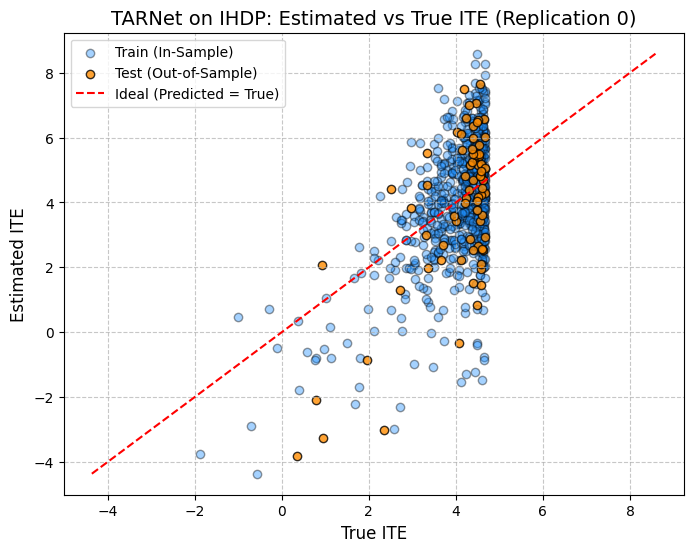

In [6]:
import matplotlib.pyplot as plt
import numpy as np

tarnet.eval()
with torch.no_grad():
    # In-Sample PEHE
    _, y0_hat_in, y1_hat_in = tarnet(x_tr, t_tr)
    ite_hat_in = (y1_hat_in - y0_hat_in).cpu().numpy()
    ite_true_in = mu1_train_all[:, rep:rep+1] - mu0_train_all[:, rep:rep+1]
    pehe_in = np.mean((ite_true_in - ite_hat_in)**2)
    
    # Out-of-Sample PEHE
    _, y0_hat_out, y1_hat_out = tarnet(x_te, t_te)
    ite_hat_out = (y1_hat_out - y0_hat_out).cpu().numpy()
    ite_true_out = mu1_test_all[:, rep:rep+1] - mu0_test_all[:, rep:rep+1]
    pehe_out = np.mean((ite_true_out - ite_hat_out)**2)

print(f"In-Sample PEHE (MSE):     {pehe_in:.4f}")
print(f"Out-of-Sample PEHE (MSE): {pehe_out:.4f}")
print(f"Out-of-Sample RMSE:       {np.sqrt(pehe_out):.4f}")

plt.figure(figsize=(8, 6))

# Plot train set
plt.scatter(ite_true_in, ite_hat_in, alpha=0.4, color='dodgerblue', edgecolor='k', label='Train (In-Sample)')

# Plot test set
plt.scatter(ite_true_out, ite_hat_out, alpha=0.8, color='darkorange', edgecolor='k', label='Test (Out-of-Sample)')

# Add y=x ideal line
min_val = min(np.min(ite_true_in), np.min(ite_hat_in), np.min(ite_true_out), np.min(ite_hat_out))
max_val = max(np.max(ite_true_in), np.max(ite_hat_in), np.max(ite_true_out), np.max(ite_hat_out))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Predicted = True)')

plt.title(f'TARNet on IHDP: Estimated vs True ITE (Replication {rep})', fontsize=14)
plt.xlabel('True ITE', fontsize=12)
plt.ylabel('Estimated ITE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 4. Counterfactual Regression (CFR)

### Intuition & Formulation
TARNet is a great baseline, but it has a hidden weakness. In observational studies, people are rarely assigned treatments at random. For example, healthier patients might be less likely to receive a high-risk drug. This is known as **selection bias** (or covariate shift), and it can cause the treated and control groups to have completely different covariate distributions. 

Without any regularization, TARNet might represent treated and control groups in entirely separate regions of the representation space $\Phi(X)$. When we try to predict a counterfactual, the model has to extrapolate to unseen regions, which can make predictions highly unreliable!

**CFR** solves this beautifully by adding an **Integral Probability Metric (IPM)** regularization penalty to the TARNet loss:

```mermaid
graph TD
    X[Covariates X] --> Phi[Shared Representation Φ]
    Phi --> H0[Hypothesis Head h0]
    Phi --> H1[Hypothesis Head h1]
    Phi -.-> IPM[IPM Balance Penalty]
    H0 -.-> Y0[Predict Y0]
    H1 -.-> Y1[Predict Y1]
    
    classDef rep fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef head fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef out fill:#f1f8e9,stroke:#33691e,stroke-width:2px;
    classDef penalty fill:#ffebee,stroke:#b71c1c,stroke-width:2px;
    
    class X,Phi rep;
    class H0,H1 head;
    class Y0,Y1 out;
    class IPM penalty;
```

Our CFR objective function is:
$$ \mathcal{L}_{CFR} = \mathcal{L}_{TARNet} + \alpha \cdot \text{IPM}\left( \{\Phi(X_i)\}_{T_i=0}, \{\Phi(X_i)\}_{T_i=1} \right) $$

We will implement two specific types of balance penalties:
1. **Maximum Mean Discrepancy (MMD)**: Measures and penalizes differences in the moments (like mean and variance) of the latent representation distributions.
2. **Wasserstein Distance**: Computes the optimal transport cost to shift one representation distribution into the other.

### Why It Excels
CFR is outstanding at handling **selection bias**! It directly penalizes the divergence between the treated and control representations, and forces the network to learn a balanced latent space where the groups heavily overlap. This ensures that predicting potential outcomes is always an interpolation task, leading to much more reliable counterfactual estimates.

In [7]:
# PyTorch implementations of MMD and Sinkhorn-Wasserstein
# Adapted directly from the original CFRNet TensorFlow codebase.

def mmd2_lin(X, t, p):
    ''' Linear MMD (Maximum Mean Discrepancy) '''
    it = (t > 0).nonzero(as_tuple=True)[0]
    ic = (t < 1).nonzero(as_tuple=True)[0]

    Xc = X[ic]
    Xt = X[it]

    # Handle edge case if a batch has no treated or no control samples
    if Xc.shape[0] == 0 or Xt.shape[0] == 0:
        return torch.tensor(0.0, device=X.device, requires_grad=True)

    mean_control = torch.mean(Xc, dim=0)
    mean_treated = torch.mean(Xt, dim=0)

    mmd = torch.sum(torch.square(2.0 * p * mean_treated - 2.0 * (1.0 - p) * mean_control))
    return mmd

def pdist2sq(X, Y):
    ''' Squared euclidean distance matrix '''
    nx = torch.sum(torch.square(X), dim=1, keepdim=True)
    ny = torch.sum(torch.square(Y), dim=1, keepdim=True)
    D = -2 * torch.matmul(X, Y.t()) + ny.t() + nx
    return D

def wasserstein(X, t, p, lam=10.0, its=10, sq=False, backpropT=False):
    ''' Sinkhorn-Knopp approximation of Wasserstein distance '''
    it = (t > 0).nonzero(as_tuple=True)[0]
    ic = (t < 1).nonzero(as_tuple=True)[0]
    Xc = X[ic]
    Xt = X[it]
    nc = float(Xc.shape[0])
    nt = float(Xt.shape[0])
    
    if nc == 0 or nt == 0:
        return torch.tensor(0.0, device=X.device, requires_grad=True)

    if sq:
        M = pdist2sq(Xt, Xc)
    else:
        M = torch.sqrt(torch.clamp(pdist2sq(Xt, Xc), min=1e-10))

    M_mean = torch.mean(M)
    delta = torch.max(M).detach()
    eff_lam = (lam / M_mean).detach()

    # Pad M
    row = delta * torch.ones(1, M.shape[1], device=X.device)
    Mt = torch.cat((M, row), dim=0)
    col = torch.cat((delta * torch.ones(M.shape[0], 1, device=X.device), torch.zeros(1, 1, device=X.device)), dim=0)
    Mt = torch.cat((Mt, col), dim=1)

    a = torch.cat((p * torch.ones(Xt.shape[0], 1, device=X.device) / nt, (1 - p) * torch.ones(1, 1, device=X.device)), dim=0)
    b = torch.cat(((1 - p) * torch.ones(Xc.shape[0], 1, device=X.device) / nc, p * torch.ones(1, 1, device=X.device)), dim=0)

    Mlam = eff_lam * Mt
    K = torch.exp(-Mlam) + 1e-6
    ainvK = K / a

    u = a
    for _ in range(its):
        u = 1.0 / torch.matmul(ainvK, (b / torch.matmul(K.t(), u)))
    v = b / torch.matmul(K.t(), u)

    T = u * (v.t() * K)

    if not backpropT:
        T = T.detach()

    E = T * Mt
    D = 2 * torch.sum(E)
    return D

### Step 1: CFRNet Architecture

Since CFR shares the exact same network layers as TARNet, we can easily build it by inheriting from our `TARNet` class.  

The only small adjustment is that our `forward` function will also return the shared representation $\Phi(X)$ so we can calculate the IPM penalty on it during training.

In [8]:
class CFRNet(TARNet):
    def forward(self, x, t):
        # 1. Get shared representation
        phi = self.phi(x)
        
        # 2. Predict counterfactuals
        y0_hat = self.h0(phi)
        y1_hat = self.h1(phi)
        
        # 3. Select factual prediction
        y_hat = (1 - t) * y0_hat + t * y1_hat
        
        # Return `phi` alongside predictions!
        return y_hat, y0_hat, y1_hat, phi

### Step 2: Training CFR-MMD

Let's train our first CFR model: **CFR-MMD**! We will use the exact same dataset replication (`rep=0`) and hyperparameters, adding the linear MMD penalty directly to our factual loss.

In [9]:
print(f"Training CFR-MMD on Realization {rep}...")

cfr_mmd = CFRNet().to(device)
optimizer_mmd = torch.optim.Adam(cfr_mmd.parameters(), lr=1e-3, weight_decay=1e-4)

# CFR hyperparameters
alpha = 1
p_treated = float(t_tr.mean())

cfr_mmd.train()
current_iter = 0
while current_iter < iterations:
    for batch_x, batch_t, batch_y in dataloader_train:
        if current_iter >= iterations:
            break
            
        optimizer_mmd.zero_grad()
        y_hat, _, _, phi = cfr_mmd(batch_x, batch_t)
        
        # Factual MSE Loss
        loss_factual = tarnet_loss(batch_y, y_hat)
        
        # MMD Penalty
        loss_ipm = mmd2_lin(phi, batch_t, p_treated)
        
        # Total Objective
        loss = loss_factual + alpha * loss_ipm
        
        loss.backward()
        optimizer_mmd.step()
        current_iter += 1

print("CFR-MMD Training complete!")

Training CFR-MMD on Realization 0...
CFR-MMD Training complete!


### Step 3: Evaluating CFR-MMD

With our CFR-MMD model trained, let's calculate its in-sample and out-of-sample PEHE and plot its predicted ITE against the ground truth to see how the MMD penalty affects performance.

CFR-MMD In-Sample PEHE (MSE):     3.2023
CFR-MMD Out-of-Sample PEHE (MSE): 3.5325


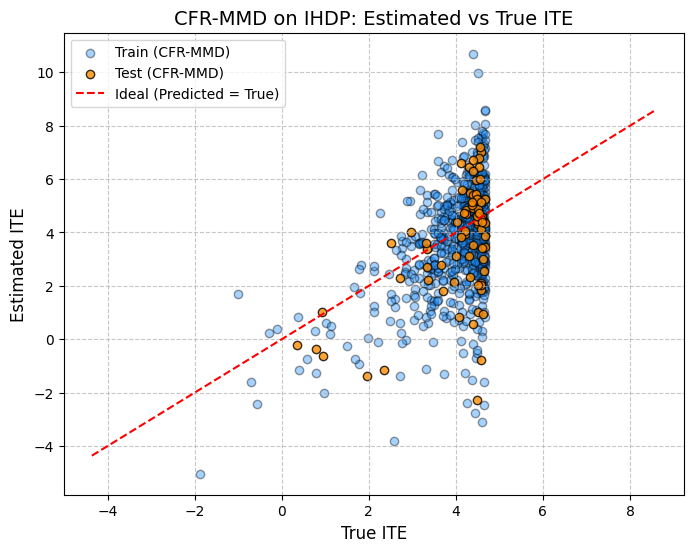

In [10]:
cfr_mmd.eval()
with torch.no_grad():
    _, y0_hat_in, y1_hat_in, _ = cfr_mmd(x_tr, t_tr)
    ite_hat_in = (y1_hat_in - y0_hat_in).cpu().numpy()
    
    _, y0_hat_out, y1_hat_out, _ = cfr_mmd(x_te, t_te)
    ite_hat_out = (y1_hat_out - y0_hat_out).cpu().numpy()

pehe_in_mmd = np.mean((ite_true_in - ite_hat_in)**2)
pehe_out_mmd = np.mean((ite_true_out - ite_hat_out)**2)

print(f"CFR-MMD In-Sample PEHE (MSE):     {pehe_in_mmd:.4f}")
print(f"CFR-MMD Out-of-Sample PEHE (MSE): {pehe_out_mmd:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(ite_true_in, ite_hat_in, alpha=0.4, color='dodgerblue', edgecolor='k', label='Train (CFR-MMD)')
plt.scatter(ite_true_out, ite_hat_out, alpha=0.8, color='darkorange', edgecolor='k', label=f'Test (CFR-MMD)')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Predicted = True)')
plt.title(f'CFR-MMD on IHDP: Estimated vs True ITE', fontsize=14)
plt.xlabel('True ITE', fontsize=12)
plt.ylabel('Estimated ITE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Step 4: Training CFR-WASS

Next, let's train **CFR-WASS** using the Wasserstein distance as the balancing penalty. This matches the exact hyperparameter setup from the original CFRNet paper for the IHDP dataset (`wass_lambda = 1.0`).

In [11]:
print(f"Training CFR-WASS on Realization {rep}...")

cfr_wass = CFRNet().to(device)
optimizer_wass = torch.optim.Adam(cfr_wass.parameters(), lr=1e-3, weight_decay=1e-4)

# CFR-WASS hyperparameters
alpha = 1
wass_lambda = 1.0

cfr_wass.train()
current_iter = 0
while current_iter < iterations:
    for batch_x, batch_t, batch_y in dataloader_train:
        if current_iter >= iterations:
            break
            
        optimizer_wass.zero_grad()
        y_hat, _, _, phi = cfr_wass(batch_x, batch_t)
        
        # Factual MSE Loss
        loss_factual = tarnet_loss(batch_y, y_hat)
        
        # Wasserstein Penalty
        loss_ipm = wasserstein(phi, batch_t, p_treated, lam=wass_lambda, its=20)
        
        # Total Objective
        loss = loss_factual + alpha * loss_ipm
        
        loss.backward()
        optimizer_wass.step()
        current_iter += 1

print("CFR-WASS Training complete!")

Training CFR-WASS on Realization 0...
CFR-WASS Training complete!


CFR-WASS In-Sample PEHE (MSE):     2.0707
CFR-WASS Out-of-Sample PEHE (MSE): 2.4864


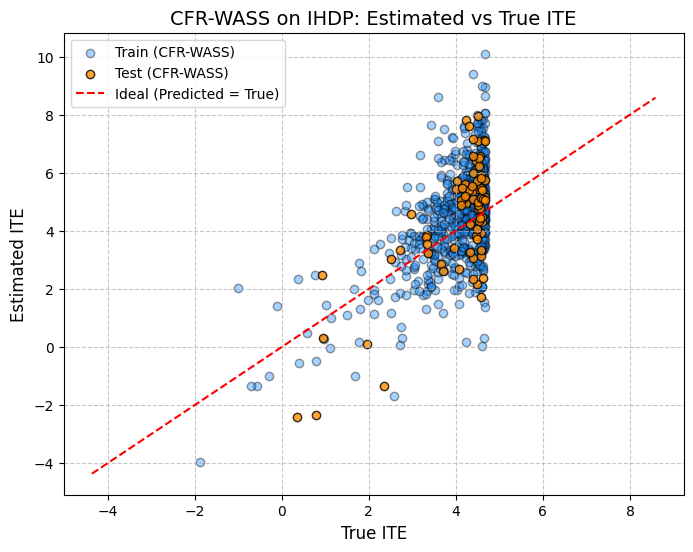

In [12]:
cfr_wass.eval()
with torch.no_grad():
    _, y0_hat_in, y1_hat_in, _ = cfr_wass(x_tr, t_tr)
    ite_hat_in = (y1_hat_in - y0_hat_in).cpu().numpy()
    
    _, y0_hat_out, y1_hat_out, _ = cfr_wass(x_te, t_te)
    ite_hat_out = (y1_hat_out - y0_hat_out).cpu().numpy()

pehe_in_wass = np.mean((ite_true_in - ite_hat_in)**2)
pehe_out_wass = np.mean((ite_true_out - ite_hat_out)**2)

print(f"CFR-WASS In-Sample PEHE (MSE):     {pehe_in_wass:.4f}")
print(f"CFR-WASS Out-of-Sample PEHE (MSE): {pehe_out_wass:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(ite_true_in, ite_hat_in, alpha=0.4, color='dodgerblue', edgecolor='k', label='Train (CFR-WASS)')
plt.scatter(ite_true_out, ite_hat_out, alpha=0.8, color='darkorange', edgecolor='k', label=f'Test (CFR-WASS)')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Predicted = True)')
plt.title(f'CFR-WASS on IHDP: Estimated vs True ITE', fontsize=14)
plt.xlabel('True ITE', fontsize=12)
plt.ylabel('Estimated ITE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5. Dragonnet

### Intuition & Formulation
While CFR focuses on forcing the representation of treated and control groups to overlap by penalizing their divergence, it runs the risk of discarding *confounding features* (features that are highly predictive of both the treatment decision and the outcome) if the IPM penalty is set too high.

**Dragonnet** takes a completely different, clever approach based on causal sufficiency. Instead of an adversarial balance penalty, Dragonnet adds a **propensity head** to the shared representation $\Phi(X)$ to explicitly predict the probability of treatment assignment $P(T=1 \mid X)$.

```mermaid
graph TD
    X[Covariates X] --> Phi[Shared Representation Φ]
    Phi --> H0[Hypothesis Head h0]
    Phi --> H1[Hypothesis Head h1]
    Phi --> Prop[Propensity Head]
    H0 -.-> Y0[Predict Y0]
    H1 -.-> Y1[Predict Y1]
    Prop -.-> T[Predict T]
    
    classDef rep fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef head fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef out fill:#f1f8e9,stroke:#33691e,stroke-width:2px;
    classDef prop fill:#f3e5f5,stroke:#4a148c,stroke-width:2px;
    
    class X,Phi rep;
    class H0,H1 head;
    class Y0,Y1,T out;
    class Prop prop;
```

The propensity prediction acts as a powerful regularizer:
$$ \mathcal{L}_{Dragonnet} = \mathcal{L}_{TARNet} + \beta \cdot \text{CrossEntropy}(T_i, p(\Phi(X_i))) $$

By forcing the shared representation to predict treatment assignment, Dragonnet guarantees that all features that confound the treatment decision are actively preserved in the representation space.

### Why It Excels
Dragonnet is a powerhouse for **statistical sufficiency** and highly efficient estimates of the Average Treatment Effect (ATE). It prevents the network from discarding vital confounding variables, ensuring that both the propensity score and outcome models are jointly optimized on a unified covariate space.

In [13]:
class Dragonnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi = SharedRepresentation(input_dim=25, hidden_dim=200)
        self.h0 = HypothesisHead(input_dim=200, hidden_dim=100)
        self.h1 = HypothesisHead(input_dim=200, hidden_dim=100)
        # Propensity score head: 2-layer MLP predicting treatment assignment
        self.propensity_head = nn.Sequential(
            nn.Linear(200, 100),
            nn.ELU(),
            nn.Linear(100, 1)
        )
        
    def forward(self, x, t):
        phi = self.phi(x)
        y0_hat = self.h0(phi)
        y1_hat = self.h1(phi)
        t_logits = self.propensity_head(phi)
        
        # Factual prediction based on treatment assignment
        y_hat = (1 - t) * y0_hat + t * y1_hat
        
        return y_hat, y0_hat, y1_hat, t_logits, phi

def dragonnet_loss(y_true, y_hat, t_true, t_logits, beta=1.0):
    """
    Computes Dragonnet loss: Factual MSE + beta * Binary Cross Entropy for treatment assignment.
    """
    mse_criterion = nn.MSELoss()
    loss_factual = mse_criterion(y_hat, y_true)
    
    bce_criterion = nn.BCEWithLogitsLoss()
    loss_propensity = bce_criterion(t_logits, t_true)
    
    total_loss = loss_factual + beta * loss_propensity
    return total_loss, loss_factual, loss_propensity

### Step 1: Training Dragonnet

Let's initialize `Dragonnet` and train it on the same realization (`rep=0`) for exactly 3000 iterations using the Adam optimizer. We'll set $\beta = 1.0$ and see how it works.

In [14]:
print(f"Training Dragonnet on Realization {rep}...")

dragonnet = Dragonnet().to(device)
optimizer_dragon = torch.optim.Adam(dragonnet.parameters(), lr=1e-3, weight_decay=1e-4)

# Dragonnet hyperparameter
beta_val = 1.0

dragonnet.train()
current_iter = 0
while current_iter < iterations:
    for batch_x, batch_t, batch_y in dataloader_train:
        if current_iter >= iterations:
            break
            
        optimizer_dragon.zero_grad()
        y_hat, _, _, t_logits, _ = dragonnet(batch_x, batch_t)
        
        # Calculate loss
        loss, _, _ = dragonnet_loss(batch_y, y_hat, batch_t, t_logits, beta=beta_val)
        
        loss.backward()
        optimizer_dragon.step()
        current_iter += 1

print("Dragonnet Training complete!")

Training Dragonnet on Realization 0...
Dragonnet Training complete!


### Step 2: Evaluating Dragonnet

Let's compute our in-sample and out-of-sample PEHE for Dragonnet and plot the estimated ITE against the true values to evaluate its prediction quality.

Dragonnet In-Sample PEHE (MSE):     2.9111
Dragonnet Out-of-Sample PEHE (MSE): 4.2399
Dragonnet Out-of-Sample RMSE:       2.0591


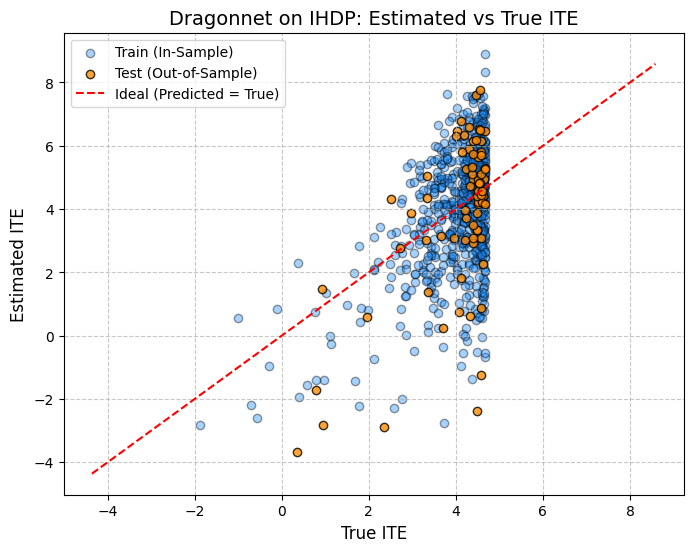

In [15]:
dragonnet.eval()
with torch.no_grad():
    # In-Sample PEHE
    _, y0_hat_in, y1_hat_in, _, _ = dragonnet(x_tr, t_tr)
    ite_hat_in = (y1_hat_in - y0_hat_in).cpu().numpy()
    
    # Out-of-Sample PEHE
    _, y0_hat_out, y1_hat_out, _, _ = dragonnet(x_te, t_te)
    ite_hat_out = (y1_hat_out - y0_hat_out).cpu().numpy()

pehe_in_dragon = np.mean((ite_true_in - ite_hat_in)**2)
pehe_out_dragon = np.mean((ite_true_out - ite_hat_out)**2)

print(f"Dragonnet In-Sample PEHE (MSE):     {pehe_in_dragon:.4f}")
print(f"Dragonnet Out-of-Sample PEHE (MSE): {pehe_out_dragon:.4f}")
print(f"Dragonnet Out-of-Sample RMSE:       {np.sqrt(pehe_out_dragon):.4f}")

plt.figure(figsize=(8, 6))

# Plot train set
plt.scatter(ite_true_in, ite_hat_in, alpha=0.4, color='dodgerblue', edgecolor='k', label='Train (In-Sample)')

# Plot test set
plt.scatter(ite_true_out, ite_hat_out, alpha=0.8, color='darkorange', edgecolor='k', label='Test (Out-of-Sample)')

# Add y=x ideal line
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Predicted = True)')

plt.title(f'Dragonnet on IHDP: Estimated vs True ITE', fontsize=14)
plt.xlabel('True ITE', fontsize=12)
plt.ylabel('Estimated ITE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Visualizing the Learned Representations

To wrap things up and truly understand how representation learning differs across all four architectures, let's visualize the high-dimensional latent representation $\Phi(X)$ that each model learns!

We will extract the 200-dimensional representations from `TARNet`, `CFR-MMD`, `CFR-WASS`, and `Dragonnet` for our training set, and use **PCA** (Principal Component Analysis) and **t-SNE** to reduce them to 2 dimensions. 

If our balance and regularization mechanisms worked as intended:
- The **CFR** models should show the Treated and Control distributions highly mixed together, as they directly penalize divergence.
- **Dragonnet** should also show a balanced/mixed representation, as predicting the propensity score forces the representation to focus on features that confound treatment, preventing easy classification separation of the groups based purely on non-confounding features.
- **TARNet** (with no penalty) might naturally allow the representations of Treated and Control groups to drift apart or form distinct clusters!

Let's run the visualization and unravel the mystery!

Running PCA & t-SNE... (t-SNE takes a few seconds)


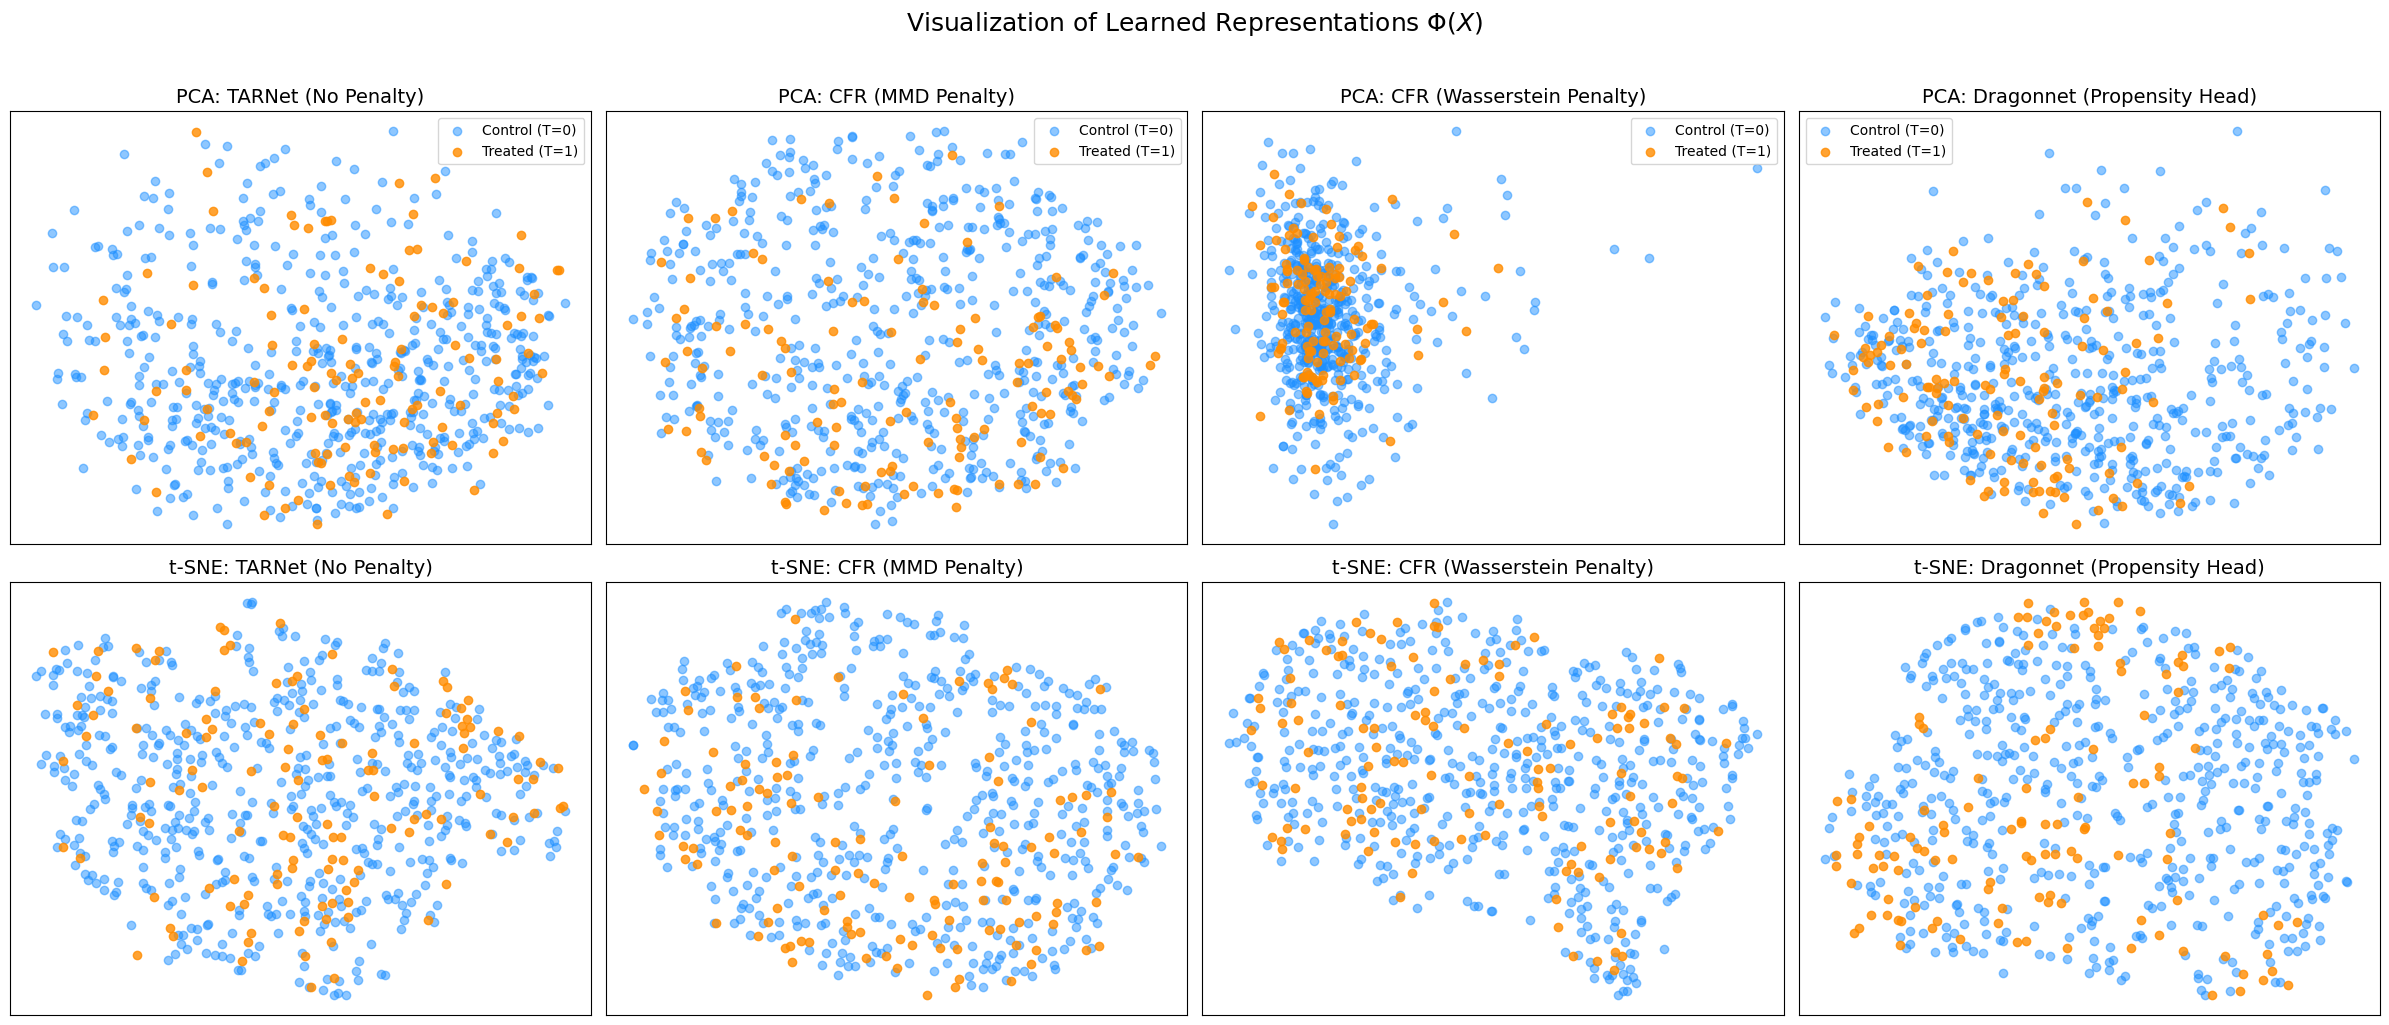

In [16]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Extract representations from the training set
tarnet.eval()
cfr_mmd.eval()
cfr_wass.eval()
dragonnet.eval()

with torch.no_grad():
    # TARNet's forward doesn't return phi, but we can call its `phi` module directly
    phi_tarnet = tarnet.phi(x_tr).cpu().numpy()
    
    # CFR returns phi directly
    _, _, _, phi_mmd = cfr_mmd(x_tr, t_tr)
    phi_mmd = phi_mmd.cpu().numpy()
    
    _, _, _, phi_wass = cfr_wass(x_tr, t_tr)
    phi_wass = phi_wass.cpu().numpy()
    
    # Dragonnet returns phi directly (5th returned element)
    _, _, _, _, phi_dragon = dragonnet(x_tr, t_tr)
    phi_dragon = phi_dragon.cpu().numpy()

# 2. Apply PCA and t-SNE
print("Running PCA & t-SNE... (t-SNE takes a few seconds)")
pca = PCA(n_components=2, random_state=42)
z_pca_tarnet = pca.fit_transform(phi_tarnet)
z_pca_mmd = pca.fit_transform(phi_mmd)
z_pca_wass = pca.fit_transform(phi_wass)
z_pca_dragon = pca.fit_transform(phi_dragon)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne_tarnet = tsne.fit_transform(phi_tarnet)
z_tsne_mmd = tsne.fit_transform(phi_mmd)
z_tsne_wass = tsne.fit_transform(phi_wass)
z_tsne_dragon = tsne.fit_transform(phi_dragon)

# 3. Plot the distributions
t_np = t_tr.cpu().numpy().flatten()
idx_t0 = (t_np == 0)
idx_t1 = (t_np == 1)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
titles = [
    'TARNet (No Penalty)', 
    'CFR (MMD Penalty)', 
    'CFR (Wasserstein Penalty)', 
    'Dragonnet (Propensity Head)'
]
pca_embeddings = [z_pca_tarnet, z_pca_mmd, z_pca_wass, z_pca_dragon]
tsne_embeddings = [z_tsne_tarnet, z_tsne_mmd, z_tsne_wass, z_tsne_dragon]

# Plot PCA
for ax, z, title in zip(axes[0], pca_embeddings, titles):
    ax.scatter(z[idx_t0, 0], z[idx_t0, 1], alpha=0.5, label='Control (T=0)', color='dodgerblue')
    ax.scatter(z[idx_t1, 0], z[idx_t1, 1], alpha=0.8, label='Treated (T=1)', color='darkorange')
    ax.set_title(f"PCA: {title}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend()

# Plot t-SNE
for ax, z, title in zip(axes[1], tsne_embeddings, titles):
    ax.scatter(z[idx_t0, 0], z[idx_t0, 1], alpha=0.5, label='Control (T=0)', color='dodgerblue')
    ax.scatter(z[idx_t1, 0], z[idx_t1, 1], alpha=0.8, label='Treated (T=1)', color='darkorange')
    ax.set_title(f"t-SNE: {title}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Visualization of Learned Representations $\\Phi(X)$', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()